<a href="https://colab.research.google.com/github/w-araujo-silva/projeto-grupo3/blob/marcelo/marcelo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

In [3]:
def carregar_banco_csv(caminho):
  # sua solução aqui
  return pd.read_csv(caminho)

In [6]:
df = carregar_banco_csv('/data_science_salaries.csv')

In [ ]:
df

,job_title,experience_level,employment_type,work_models,work_year,employee_residence,salary,salary_currency,salary_in_usd,company_location,company_size
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium
...,...,...,...,...,...,...,...,...,...,...,...
6594,Staff Data Analyst,Entry-level,Contract,Hybrid,2020,Canada,60000,CAD,44753,Canada,Large
6595,Staff Data Analyst,Executive-level,Full-time,On-site,2020,Nigeria,15000,USD,15000,Canada,Medium
6596,Machine Learning Manager,Senior-level,Full-time,Hybrid,2020,Canada,157000,CAD,117104,Canada,Large
6597,Data Engineer,Mid-level,Full-time,Hybrid,2020,Austria,65000,EUR,74130,Austria,Large


### Onde estão as melhores oportunidades?
Quais países têm os maiores salários médios?



In [7]:
# 1. Países com os maiores salários médios
# Agrupamos pelo país de residência e calculamos a média da coluna de salário
salarios_por_pais = df.groupby('employee_residence')['salary_in_usd'].mean()

# Ordenamos do maior para o menor e mostramos os 10 primeiros
melhores_oportunidades = salarios_por_pais.sort_values(ascending=False).head(10)

print("Top 10 países com maiores salários médios:")
print(melhores_oportunidades)

Top 10 países com maiores salários médios:
employee_residence
Israel                    417937.000000
Qatar                     300000.000000
Malaysia                  200000.000000
Puerto Rico               166000.000000
United States             157780.939680
New Zealand               151634.333333
Canada                    140564.883817
Saudi Arabia              134999.000000
China                     125404.000000
Bosnia and Herzegovina    120000.000000
Name: salary_in_usd, dtype: float64


### Análise dos Países com Maiores Salários

Ao observar os resultados, podemos notar alguns pontos importantes:

1. ** Países como **Israel, Catar e Malásia** aparecem no topo. Isso pode ter acontecido porque a base pode ter poucos registros desses locais, mas que são de cargos altos, elevando a média.
2. Os **Estados Unidos** aparecem com uma média de aproximadamente **$157.780**. Diferente dos primeiros da lista, os EUA possuem a maior quantidade de dados no dataset, o que torna essa média muito robusta e representativa do mercado local.
3. **Canadá** e **Porto Rico** também se destacam, mostrando que a região da América do Norte (ou territórios vinculados) oferece algumas das melhores remunerações em dólar para Data Science.
4. A presença de países como **Nova Zelândia** e **Arábia Saudita** no Top 10 indica que o mercado de dados é globalmente valorizado, com polos de alta remuneração espalhados por diferentes continentes.

### Existe correlação entre país e modalidade de trabalho (remoto vs presencial)?

In [8]:
# Analisando a relação entre país e modalidade de trabalho
# Primeiro, selecionamos os 10 países com mais registros para ter uma base sólida
paises_principais = df['employee_residence'].value_counts().head(10).index
dados_filtrados = df[df['employee_residence'].isin(paises_principais)]

# Criamos uma tabela cruzada (crosstab) para ver a contagem de cada modalidade por país
# Usamos 'normalize="index"' para ver a proporção (porcentagem) em vez de apenas números brutos
correlacao_trabalho = pd.crosstab(dados_filtrados['employee_residence'], dados_filtrados['work_models'], normalize='index') * 100

print("Porcentagem de cada modalidade de trabalho por país (Top 10 países):")
display(correlacao_trabalho.round(2))

Porcentagem de cada modalidade de trabalho por país (Top 10 países):


work_models,Hybrid,On-site,Remote
employee_residence,,,
Australia,13.79,58.62,27.59
Canada,6.22,45.64,48.13
France,43.40,13.21,43.40
Germany,30.99,33.80,35.21
India,32.86,14.29,52.86
Netherlands,28.57,28.57,42.86
Portugal,17.86,32.14,50.00
Spain,7.46,32.84,59.70
United Kingdom,5.24,63.34,31.42


### Preferências por País

Podemos notar que países como a Espanha e a Índia possuem uma forte inclinação para o trabalho Remoto (59.7% e 52.86%, respectivamente).

Já nos Estados Unidos e no Reino Unido (United Kingdom), a modalidade On-site (presencial) é predominante, ultrapassando os 60%.

A França se destaca com uma das maiores taxas de trabalho Híbrido (43.4%) entre os países analisados.

Essa tabela ajuda a entender onde você tem mais chances de encontrar a modalidade de trabalho que prefere!

### Visualização: Média Salarial por Nível de Experiência
Como o salário varia conforme o nível de experiência?

<Axes: title={'center': 'Média Salarial por Nível de Experiência (USD)'}, xlabel='Nível de Experiência', ylabel='Salário Médio'>

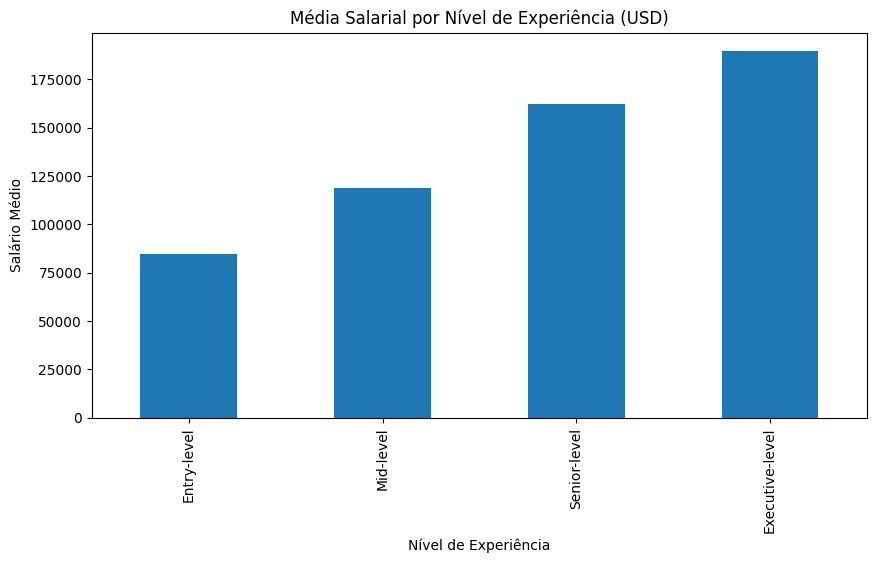

In [14]:
# Calculamos a média salarial agrupada por nível de experiência
media_experiencia = df.groupby('experience_level')['salary_in_usd'].mean().sort_values()

# Criamos um gráfico de barras simples
media_experiencia.plot(kind='bar', title='Média Salarial por Nível de Experiência (USD)', ylabel='Salário Médio', xlabel='Nível de Experiência', figsize=(10, 5))

### Crescimento Constante:
Existe um aumento claro e direto na remuneração à medida que o nível de experiência aumenta.


### Total de Registros
Quantas linhas de dados temos no total?

In [16]:
total_registros = len(df)
print(f"O conjunto de dados possui um total de {total_registros} registros.")

O conjunto de dados possui um total de 6599 registros.


### Quantidade de Registros por País
Vamos verificar quantos profissionais de cada país estão presentes neste conjunto de dados.

In [15]:
# Contamos a quantidade de registros por país de residência
contagem_paises = df['employee_residence'].value_counts()

# Exibimos os resultados (mostrando os 20 principais para não poluir a tela)
print("Quantidade de registros por país (Top 20):")
display(contagem_paises.head(20))

Quantidade de registros por país (Top 20):


,count
employee_residence,
United States,5305
United Kingdom,401
Canada,241
Germany,71
India,70
Spain,67
France,53
Australia,29
Portugal,28


A base de dados possui 6599 registros no total.

Deste total, 5305 são registros dos Estados Unidos (80,39%).

Em segundo lugar está o Reino unido com apenas 401 registros (6,07%).

Com mais de 80% dos dados concentrados nos EUA, as médias de outros países podem ser facilmente distorcidas por poucos registros, o que torna a comparação direta entre países estatisticamente frágil. Isto torma esta base mais indicada para outras variáveis com melhor distribuição, como evolução salarial, cargos mais valorizados, impacto do tamanho da empresa,...